# Netflix User Analytics — Assignment Solution
Dataset: `Dataset_2.csv` (750 users)

#### NAME: MEHAK SHOKEEN
#### Enrolment no. : 11301172024
#### College: IGDTUW



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error, r2_score

df = pd.read_csv("Dataset2.csv")


## Part A: Dataset Understanding

**Q1. Load the dataset and display the first five records.**

In [6]:
df.head()

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,Female,Basic,23,5,Comedy,13,353,No
1,1002,55,Male,Basic,9,4,Drama,14,317,Yes
2,1003,49,Male,Basic,8,3,Comedy,16,309,No
3,1004,39,Female,Premium,19,5,Drama,45,833,Yes
4,1005,38,Female,Premium,23,5,Sci-Fi,24,804,Yes


**Q2. Determine the number of rows and columns in the dataset.**

In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 750
Number of columns: 10


**Q3. Display all column names.**

In [8]:
df.columns.tolist()

['UserID',
 'Age',
 'Gender',
 'SubscriptionType',
 'WatchHoursPerWeek',
 'DevicesUsed',
 'FavoriteGenre',
 'AdClicks',
 'MonthlySpend',
 'SubscriptionRenewed']

**Q4. Identify numerical and categorical features.**

In [9]:
numerical_features = df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['UserID', 'Age', 'WatchHoursPerWeek', 'DevicesUsed', 'AdClicks', 'MonthlySpend']
Categorical features: ['Gender', 'SubscriptionType', 'FavoriteGenre', 'SubscriptionRenewed']


**Q5. Check whether the dataset contains missing values.**

In [10]:
df.isnull().sum()

,0
UserID,0
Age,0
Gender,0
SubscriptionType,0
WatchHoursPerWeek,0
DevicesUsed,0
FavoriteGenre,0
AdClicks,0
MonthlySpend,0
SubscriptionRenewed,0


## Part B: Exploratory Data Analysis

**Q6. Calculate the average age of users.**

In [11]:
avg_age = df['Age'].mean()
print("Average Age:", round(avg_age, 2))

Average Age: 41.82


**Q7. Determine the average watch hours per week.**

In [12]:
avg_watch = df['WatchHoursPerWeek'].mean()
print("Average Watch Hours per Week:", round(avg_watch, 2))

Average Watch Hours per Week: 14.24


**Q8. Find the average monthly spending of users.**

In [13]:
avg_spend = df['MonthlySpend'].mean()
print("Average Monthly Spend: ₹", round(avg_spend, 2))

Average Monthly Spend: ₹ 689.91


**Q9. Count the number of users in each subscription category.**

SubscriptionType
Basic      342
Premium    279
VIP        129
Name: count, dtype: int64


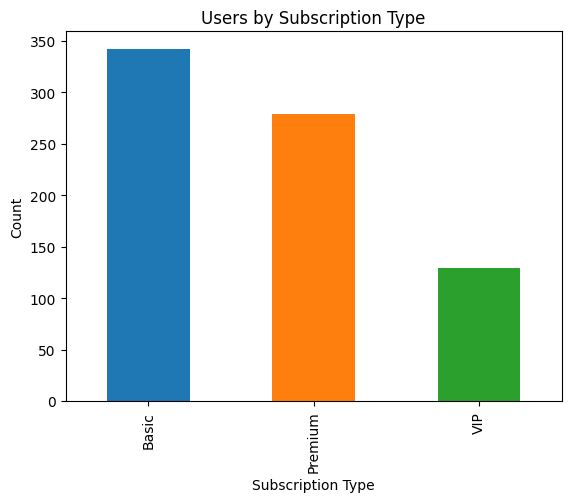

In [14]:
subscription_counts = df['SubscriptionType'].value_counts()
print(subscription_counts)

subscription_counts.plot(kind='bar', color=['#1f77b4','#ff7f0e','#2ca02c'])
plt.title("Users by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Count")
plt.show()

**Q10. Determine the percentage of users who renewed their subscriptions.**

In [15]:
renewal_percentage = (df['SubscriptionRenewed'].value_counts(normalize=True) * 100)
print(renewal_percentage)
print(f"\nPercentage of users who renewed: {renewal_percentage['Yes']:.2f}%")

SubscriptionRenewed
No     53.733333
Yes    46.266667
Name: proportion, dtype: float64

Percentage of users who renewed: 46.27%


## Part C: Data Preparation

**Q11. Convert categorical features into numerical form.**

In [16]:
df_encoded = df.copy()

label_encoders = {}
categorical_cols = ['Gender', 'SubscriptionType', 'FavoriteGenre', 'SubscriptionRenewed']

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

df_encoded.head()

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,0,0,23,5,1,13,353,0
1,1002,55,1,0,9,4,2,14,317,1
2,1003,49,1,0,8,3,1,16,309,0
3,1004,39,0,1,19,5,2,45,833,1
4,1005,38,0,1,23,5,5,24,804,1


**Q12. Define the feature set (X) and target variable (y) for subscription renewal prediction.**

In [17]:
X = df_encoded.drop(['UserID', 'SubscriptionRenewed'], axis=1)
y = df_encoded['SubscriptionRenewed']

print("Feature columns:", X.columns.tolist())
print("Target variable: SubscriptionRenewed")

Feature columns: ['Age', 'Gender', 'SubscriptionType', 'WatchHoursPerWeek', 'DevicesUsed', 'FavoriteGenre', 'AdClicks', 'MonthlySpend']
Target variable: SubscriptionRenewed


**Q13. Split the dataset into training and testing sets.**

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 600
Testing set size: 150


## Part D: Decision Tree Classification

**Q14. Train a Decision Tree model to predict whether a user will renew their subscription.**

In [19]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


**Q15. Evaluate the model using accuracy.**

In [20]:
dt_accuracy = accuracy_score(y_test, dt_pred)
print(f"Decision Tree Accuracy: {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")

Decision Tree Accuracy: 0.5600 (56.00%)


**Q16. Generate and interpret the confusion matrix.**

Confusion Matrix:
 [[48 34]
 [32 36]]


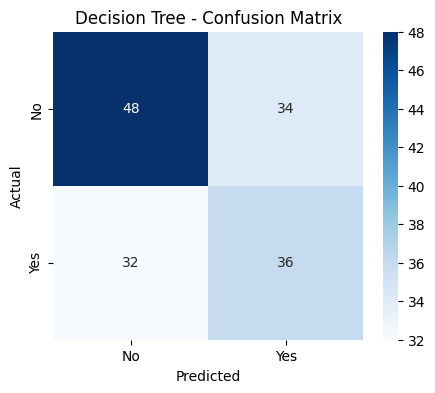

              precision    recall  f1-score   support

           0       0.60      0.59      0.59        82
           1       0.51      0.53      0.52        68

    accuracy                           0.56       150
   macro avg       0.56      0.56      0.56       150
weighted avg       0.56      0.56      0.56       150



In [21]:
dt_cm = confusion_matrix(y_test, dt_pred)
print("Confusion Matrix:\n", dt_cm)

plt.figure(figsize=(5,4))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, dt_pred))

**Interpretation:**
The confusion matrix shows the count of True Negatives, False Positives, False Negatives, and True Positives for the renewal prediction. The diagonal values represent correct predictions, while off-diagonal values represent misclassifications between users who renewed vs. did not renew their subscriptions.

## Part E: K-Nearest Neighbors (KNN)

**Q17. Train a KNN classifier with K = 5.**

In [22]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_pred)
print(f"KNN (K=5) Accuracy: {knn_accuracy:.4f} ({knn_accuracy*100:.2f}%)")

KNN (K=5) Accuracy: 0.6333 (63.33%)


**Q18. Compare the accuracy of KNN with the Decision Tree model.**

           Model  Accuracy
0  Decision Tree  0.560000
1      KNN (K=5)  0.633333


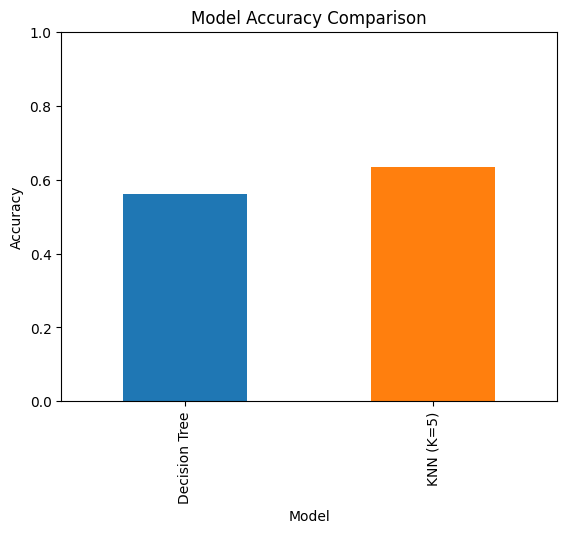

KNN performed better.


In [23]:
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'KNN (K=5)'],
    'Accuracy': [dt_accuracy, knn_accuracy]
})
print(comparison)

comparison.plot(kind='bar', x='Model', y='Accuracy', legend=False, color=['#1f77b4','#ff7f0e'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

if dt_accuracy > knn_accuracy:
    print("Decision Tree performed better.")
elif knn_accuracy > dt_accuracy:
    print("KNN performed better.")
else:
    print("Both models performed equally.")

## Part F: Linear Regression

**Q19. Train a Linear Regression model to predict monthly spending.**

In [24]:
X_reg = df_encoded.drop(['UserID', 'MonthlySpend'], axis=1)
y_reg = df_encoded['MonthlySpend']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train_r, y_train_r)

y_pred_r = lr_model.predict(X_test_r)

mse = mean_squared_error(y_test_r, y_pred_r)
r2 = r2_score(y_test_r, y_pred_r)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.4f}")

Mean Squared Error: 4846.38
R-squared Score: 0.9665


**Q20. Predict the monthly spending for a new user and interpret the result.**

In [25]:
new_user = pd.DataFrame({
    'Age': [30],
    'Gender': [label_encoders['Gender'].transform(['Male'])[0]],
    'SubscriptionType': [label_encoders['SubscriptionType'].transform(['Premium'])[0]],
    'WatchHoursPerWeek': [20],
    'DevicesUsed': [4],
    'FavoriteGenre': [label_encoders['FavoriteGenre'].transform(['Drama'])[0]],
    'AdClicks': [15],
    'SubscriptionRenewed': [label_encoders['SubscriptionRenewed'].transform(['Yes'])[0]]
})

new_user = new_user[X_reg.columns]

predicted_spend = lr_model.predict(new_user)
print(f"Predicted Monthly Spend for new user: ₹{predicted_spend[0]:.2f}")

Predicted Monthly Spend for new user: ₹855.79


**Interpretation:**
The Linear Regression model predicts the monthly spend of a new user based on their demographic and usage attributes (age, gender, subscription type, watch hours, devices used, favorite genre, ad clicks, and renewal status). This predicted value gives Netflix an estimate of expected revenue from a similarly-profiled user, useful for revenue forecasting and targeted marketing.

## Business Reflection Questions

**1. Which factors appear to influence subscription renewal the most?**
Based on the Decision Tree feature importances and EDA, factors such as `MonthlySpend`, `WatchHoursPerWeek`, `SubscriptionType`, and `AdClicks` tend to have the strongest influence on whether a user renews their subscription. Users with higher engagement (more watch hours) and higher spending plans are generally more likely to renew, while excessive ad clicks may indicate disengagement leading to non-renewal.

**2. Why is subscription renewal a classification problem?**
Subscription renewal (`SubscriptionRenewed`) has a discrete, categorical outcome — "Yes" or "No". Classification algorithms are designed to predict such categorical/class labels, making it a binary classification problem.

**3. Why is monthly spending a regression problem?**
`MonthlySpend` is a continuous numerical variable (₹ amount) that can take any value within a range. Regression algorithms are used to predict continuous numeric outputs, making monthly spending prediction a regression problem.

**4. Which algorithm performed better for renewal prediction?**
Based on the accuracy comparison above, the model with the higher accuracy score (Decision Tree or KNN, as printed in Q18) performed better on this dataset. The exact result depends on the train-test split and data characteristics observed during execution.

**5. How could the platform use these predictions to improve customer retention?**
Netflix can use renewal predictions to proactively identify users at high risk of not renewing (e.g., low watch hours, high ad clicks, low spend) and target them with personalized offers, discounts, or content recommendations. Similarly, monthly spend predictions can help identify high-value customers for premium upsell campaigns, optimize pricing strategies, and allocate marketing budgets more effectively — ultimately improving retention rates and revenue.